# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

In [1]:
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil, log2, sqrt
from scipy import signal
from numpy import fft
from scipy.io.wavfile import read
from scipy.fftpack import fftshift 
from IPython.display import Image, Audio
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.signal import stft
from librosa import feature, frames_to_time, autocorrelate, clicks, display
from librosa.feature import zero_crossing_rate, mfcc, spectral_bandwidth, spectral_centroid, spectral_rolloff, chroma_stft

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [2]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    if sqrt(frame_size) % 2 == 0:
        frame_length = frame_size
    else:
        frame_length = 2**ceil(log2(frame_size))

    # Define hop size is half the frame size
    hop_length = int(frame_length / 2)

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = (len(audio_input) - frame_length)//(hop_length) + 1
    n_mbins = int(n_mbins)

    # Define total number of frequency bins
    n_kbins = (frame_length //2) + 1
    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins, n_kbins), dtype=complex)

    # Define window
    window = np.hanning(frame_length)
    

    # Iterate through signal by frame
    for m in range(n_mbins):
        frame = (audio_input[m*hop_length:(m*hop_length) + frame_length]) * window
        spectrum = np.fft.rfft(frame)

        stft_matrix[m, :] = spectrum

    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [3]:
country_fs, country = read('../audio/country.00000.wav')
country = country/abs(country).max()
hiphop_fs, hiphop = read('../audio/hiphop.00000.wav')
hiphop = hiphop/abs(hiphop).max()

countrySTFT = my_stft(country, 128, country_fs)
hiphopSTFT = my_stft(hiphop, 128, hiphop_fs)


countrySTFT


array([[-15.36077203+0.j        ,  11.62199041+6.66296558j,
         -4.59164576-4.68796081j, ...,  -0.05185196-0.04172675j,
         -0.21456503-0.04608394j,   0.41415643+0.j        ],
       [ 15.28808305+0.j        , -10.10889065+5.02537734j,
          1.74479037-3.70808917j, ...,  -0.259313  -0.09440317j,
          0.10596298+0.12979471j,   0.06947703+0.j        ],
       [  5.01086981+0.j        ,  -2.44155298-4.86453549j,
         -0.97837335-2.02563939j, ...,   0.10230251-0.19733915j,
         -0.11876933+0.14667323j,   0.13462088+0.j        ],
       ...,
       [  4.61608925+0.j        ,  -6.49058924-8.10217544j,
          5.59763029+6.85804499j, ...,  -0.03682164-0.01871651j,
          0.02845929+0.01152546j,  -0.04987228+0.j        ],
       [ -8.48455846+0.j        ,   5.09442002+4.12834529j,
         -1.14594864+0.12035989j, ...,   0.10581202+0.06781703j,
         -0.09949921-0.03722274j,   0.09202093+0.j        ],
       [  5.93920369+0.j        ,  -0.47222887+5.84227577j

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


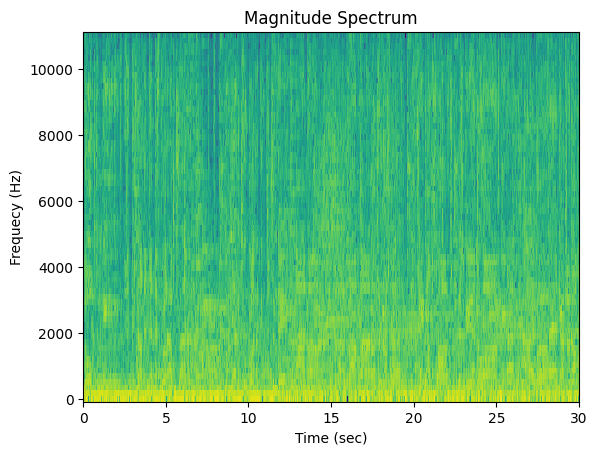

In [4]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames =  stft_matrix.shape[0]
    hop_size =    frame_size // 2
    duration =    (num_frames * hop_size) // sampling_rate

    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0, duration, num_frames)
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0, sampling_rate // 2, np.size(stft_matrix, axis=1))

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    plt.pcolormesh(time_axis, freq_axis, magnitude_db)
    plt.xlabel('Time (sec)')
    plt.ylabel('Frequecy (Hz)')
    plt.title('Magnitude Spectrum')
    plt.show()


plot_spectrogram(countrySTFT, 128, country_fs)

    

Plot the spectrogram of the country and hiphop audio files

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

C:\Users\rowan\AppData\Local\Temp\ipykernel_23436\3748063925.py:2: FutureWarning: Pass y=[-0.17154617 -0.02200421  0.01983783 ...  0.07771107  0.03927333
 -0.0213543 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphopRMS = librosa.feature.rms(hiphop.astype(float))
C:\Users\rowan\AppData\Local\Temp\ipykernel_23436\3748063925.py:5: FutureWarning: Pass y=[-0.17343275 -0.25190358 -0.0550361  ...  0.29222393  0.19446088
  0.05479938] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  countryRMS = librosa.feature.rms(country.astype(float))


Text(0, 0.5, 'Energy')

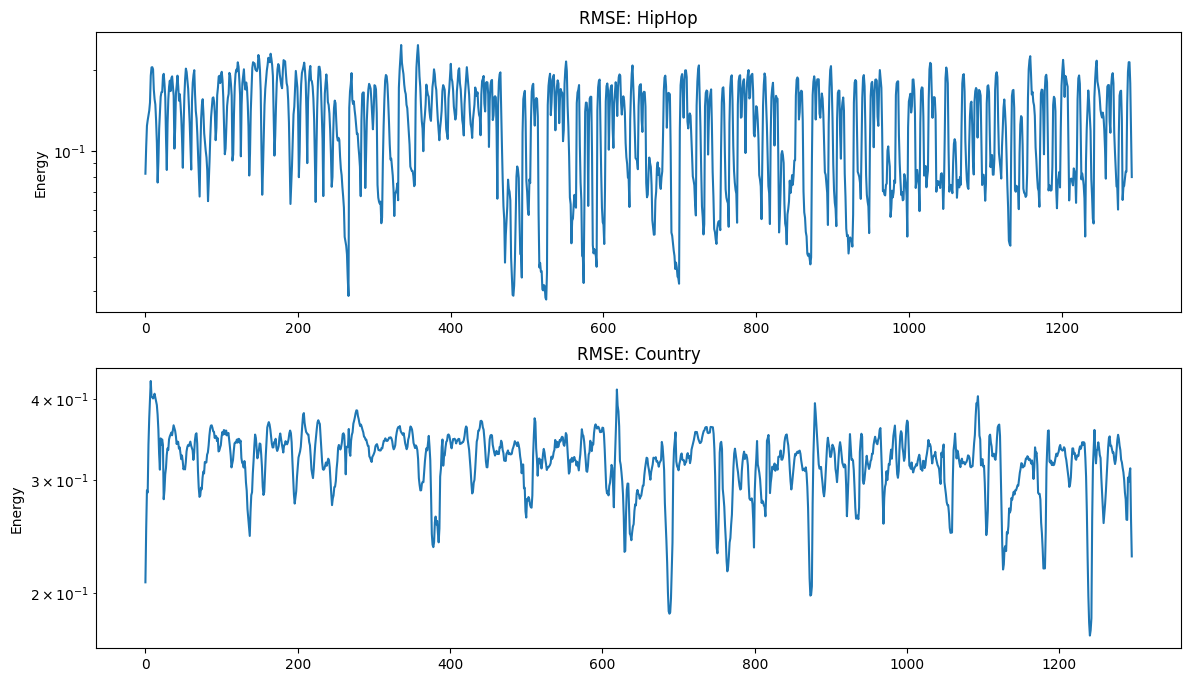

In [5]:
# RMSE for hiphop
hiphopRMS = librosa.feature.rms(hiphop.astype(float))

# RMSE for country
countryRMS = librosa.feature.rms(country.astype(float))
# plotting

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphopRMS[0])
plt.title('RMSE: HipHop')
plt.ylabel('Energy')
plt.subplot(2,1,2)
plt.semilogy(countryRMS[0])
plt.title('RMSE: Country')
plt.ylabel('Energy')


***************
Similarly to the energy of a signal, RMSE measures the strength of a signal. The RMSE is used for more than just the normal energy calculation, because it can show the average energy over the course of a larger piece than just a frame.
***************

C:\Users\rowan\AppData\Local\Temp\ipykernel_23436\3304587837.py:2: FutureWarning: Pass y=[-0.17154617 -0.02200421  0.01983783 ...  0.07771107  0.03927333
 -0.0213543 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphopCentroid = librosa.feature.spectral_centroid(hiphop.astype(float))
C:\Users\rowan\AppData\Local\Temp\ipykernel_23436\3304587837.py:4: FutureWarning: Pass y=[-0.17343275 -0.25190358 -0.0550361  ...  0.29222393  0.19446088
  0.05479938] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  countryCentroid = librosa.feature.spectral_centroid(country.astype(float))


Text(0, 0.5, 'Energy')

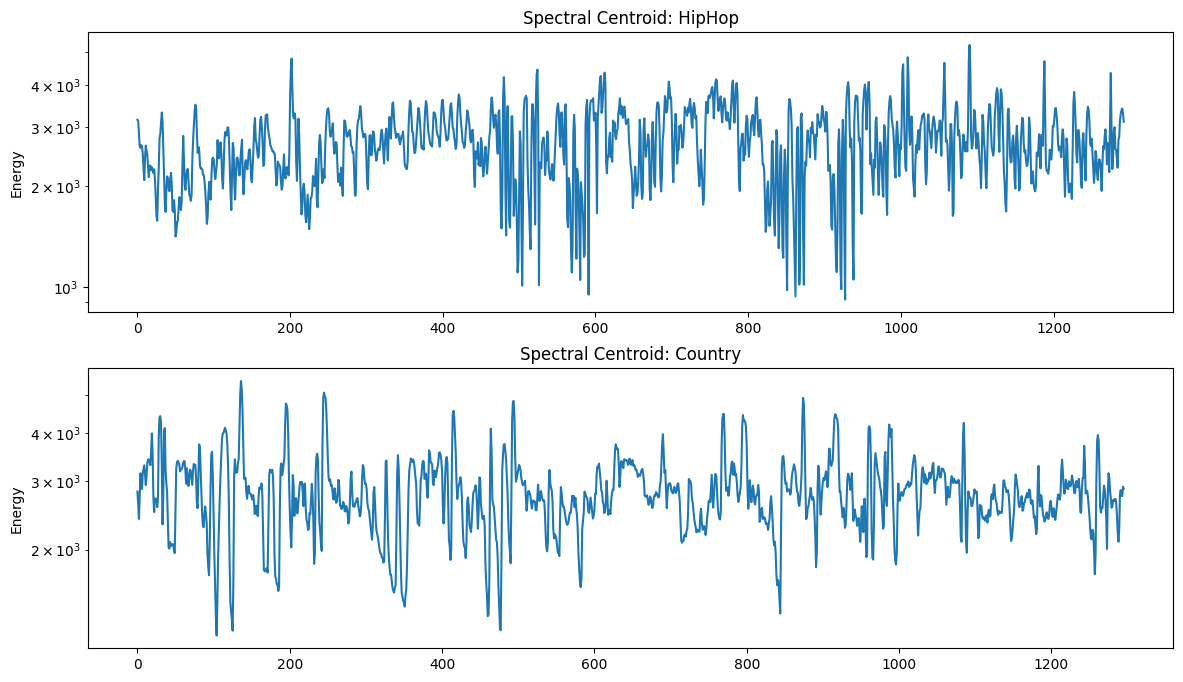

In [6]:
# Spectral Centroid for hiphop
hiphopCentroid = librosa.feature.spectral_centroid(hiphop.astype(float))
# Spectral Centroid for country
countryCentroid = librosa.feature.spectral_centroid(country.astype(float))


# plotting
plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.semilogy(hiphopCentroid[0])
plt.title('Spectral Centroid: HipHop')
plt.ylabel('Energy')
plt.subplot(2,1,2)
plt.semilogy(countryCentroid[0])
plt.title('Spectral Centroid: Country')
plt.ylabel('Energy')

***************
Spectral Centroid can be described approximately as the center of mass of a signal's spectrum. It shows where the majority of the signal's frequency is on the frequency axis, which can be used to show different timbral elements.
***************

Text(0, 0.5, 'Flux')

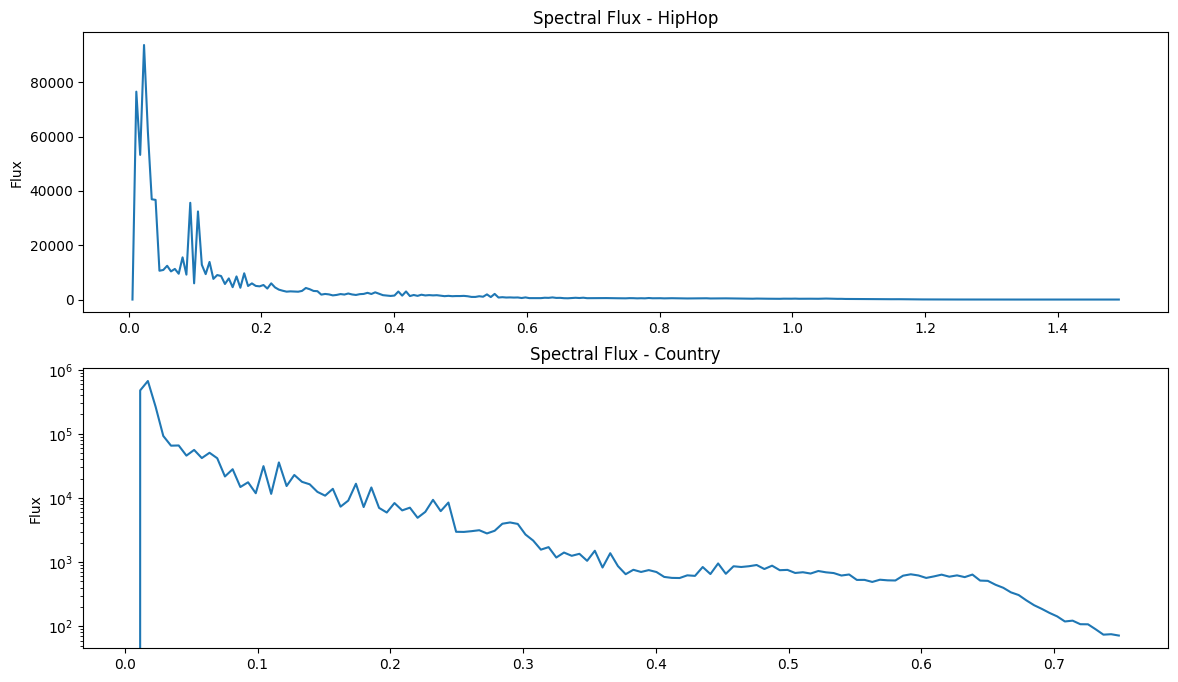

In [7]:
countrySTFT = my_stft(country, 159, country_fs)
hiphopSTFT = my_stft(hiphop, 259, hiphop_fs)

frame_length = 512
hop_length = 128


magnitude = np.abs(hiphopSTFT)

# Frame-to-frame difference
diff = np.diff(magnitude, axis=1)

# Square and sum across frequency bins
hiphop_flux = np.sum(diff**2, axis=0)

# Pad so output matches frame count
hiphop_flux = np.concatenate(([0], hiphop_flux))

frames = range(1,len(hiphop_flux)+1) #vector of frames as iterable
hiphop_t = frames_to_time(frames, sr=hiphop_fs, hop_length=hop_length)




magnitude = np.abs(countrySTFT)

# Frame-to-frame difference
diff = np.diff(magnitude, axis=1)

# Square and sum across frequency bins
country_flux = np.sum(diff**2, axis=0)

# Pad so output matches frame count
country_flux = np.concatenate(([0], country_flux))

frames = range(1,len(country_flux)+1) #vector of frames as iterable
country_t = frames_to_time(frames, sr=country_fs, hop_length=hop_length)

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.plot(hiphop_t, hiphop_flux)
plt.title('Spectral Flux - HipHop')
plt.ylabel('Flux')
plt.subplot(2,1,2)
plt.semilogy(country_t, country_flux)
plt.title('Spectral Flux - Country')
plt.ylabel('Flux')

***************
Spectral Flux is the measurement of the spectral shape (how quickly the power structure changes in) a given signal. This measurement is found by comparing the value of each magnitude spectrum bin in the current bin to the one in the previous bin. This is used to help determine the timbre of an audio signal. 
***************

C:\Users\rowan\AppData\Local\Temp\ipykernel_23436\3495327375.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,0.3)
C:\Users\rowan\AppData\Local\Temp\ipykernel_23436\3495327375.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,0.3)


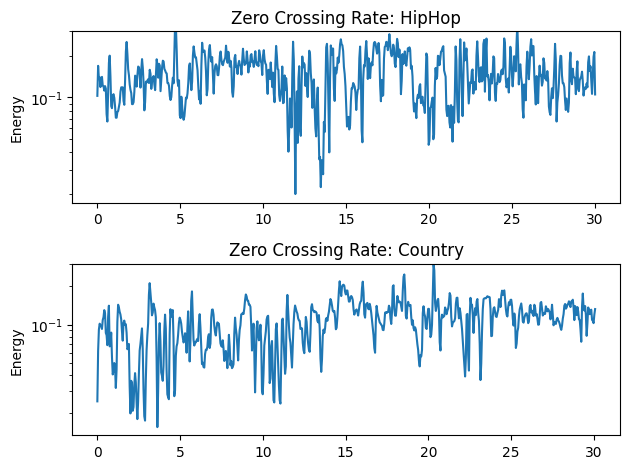

In [8]:
# ZCR for hiphop
hiphopZCR = librosa.feature.zero_crossing_rate(hiphop.astype(float))
# ZCR for country
countryZCR = librosa.feature.zero_crossing_rate(country.astype(float))

a = librosa.feature.zero_crossing_rate(hiphop.astype(float), hop_length=1024)
b = librosa.feature.zero_crossing_rate(country.astype(float), hop_length=1024)

ax1 = np.linspace(0,len(hiphop)/hiphop_fs,len(a[0]))
ax2 = np.linspace(0,len(country)/country_fs,len(b[0]))

# plotting
plt.subplot(2,1,1)
plt.semilogy(ax1, a[0])
plt.ylim(0,0.3)
plt.title('Zero Crossing Rate: HipHop')
plt.ylabel('Energy')
plt.subplot(2,1,2)
plt.semilogy(ax2, b[0])
plt.ylim(0,0.3)
plt.title('Zero Crossing Rate: Country')
plt.ylabel('Energy')
plt.tight_layout()


***************
Zero Crossing Rate is a calculation of how many times the signal crosses from a positive to a negative point in a given audio signal. ZCR can also be interpreted as the "noisiness" of a signal, because it is higher in high, "noisy" parts of signal. Due to this, the ZCR can be used to measure the dominant frequency of a specific frame.
***************

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

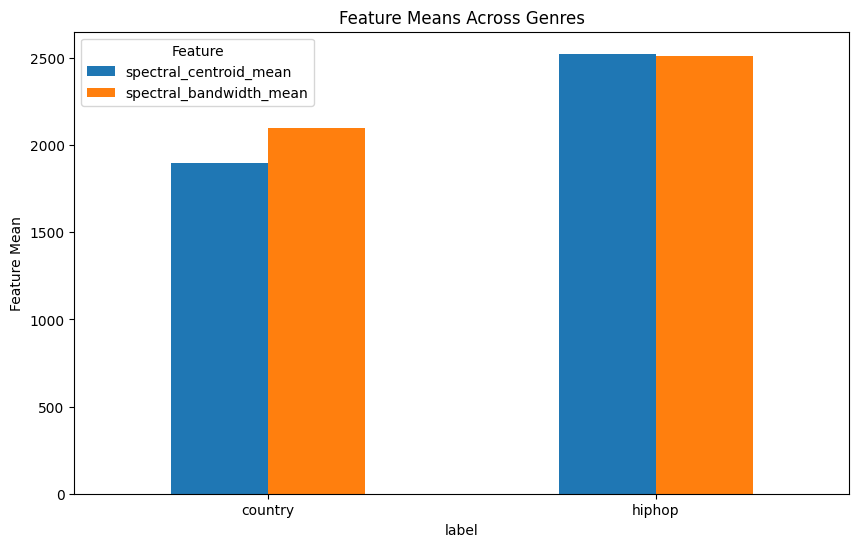

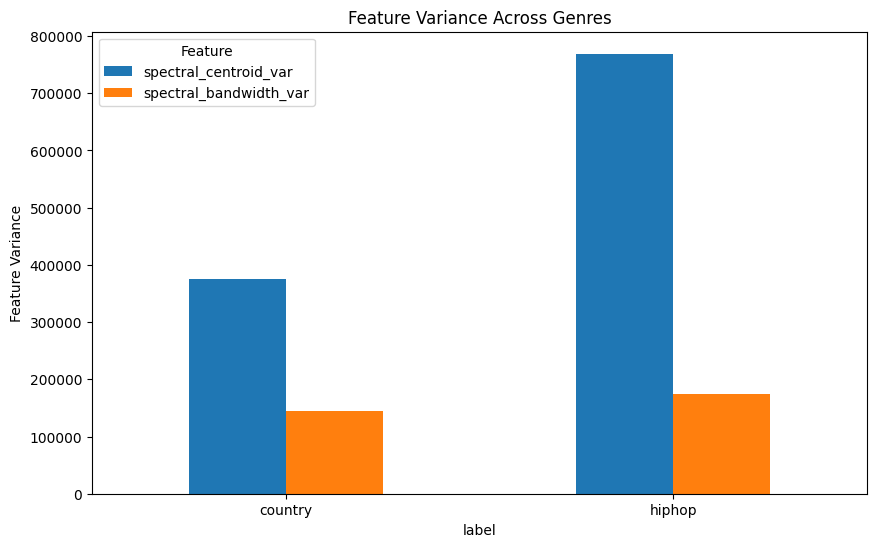

<AxesSubplot: title={'center': 'harmony_mean'}, xlabel='label'>

<Figure size 640x480 with 0 Axes>

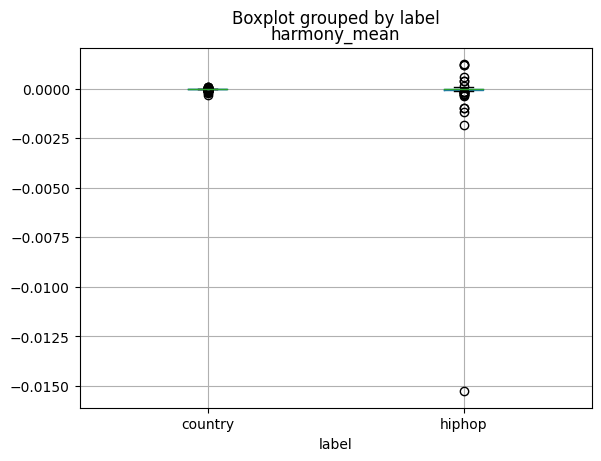

In [13]:
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt, matplotlib


data = pd.read_csv('../Datasets/Features_30_sec.csv')

dataFilt = data[data['label'].isin(['country', 'hiphop'])]

grouped = dataFilt.groupby("label").mean(numeric_only=True)
features = [
    "spectral_centroid_mean",
    'spectral_bandwidth_mean'
   
    
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Feature Mean by label')
plt.ylabel("Feature Mean")
plt.title("Feature Means Across Genres")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

grouped2 = dataFilt.groupby("label").mean(numeric_only=True)
features2 = [
    'spectral_centroid_var',
    "spectral_bandwidth_var",
    
   
    
]

grouped_features2 = grouped2[features2]
grouped_features2.plot.bar(figsize=(10, 6), title='Feature Variance by label')
plt.ylabel("Feature Variance")
plt.title("Feature Variance Across Genres")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()



plt.figure()
dataFilt.boxplot(column="harmony_mean", by="label")


 

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [16]:
dataFeatures = dataFilt[['label', 'spectral_centroid_mean',
    'spectral_bandwidth_mean', 'spectral_centroid_var',
    "spectral_bandwidth_var", "harmony_mean"]]


label = pd.get_dummies(dataFeatures['label'], drop_first=True)
spectral_centroid_mean = pd.get_dummies(dataFeatures['spectral_centroid_mean'], drop_first=True)
spectral_bandwidth_mean = pd.get_dummies(dataFeatures['spectral_bandwidth_mean'], drop_first=True)
spectral_centroid_var = pd.get_dummies(dataFeatures['spectral_centroid_var'], drop_first=True)
spectral_bandwidth_var = pd.get_dummies(dataFeatures['spectral_bandwidth_var'], drop_first=True)
harmony_mean = pd.get_dummies(dataFeatures['harmony_mean'], drop_first=True)

dataDummy = pd.concat([label,spectral_centroid_mean, spectral_bandwidth_mean, spectral_centroid_var, spectral_centroid_var, harmony_mean], axis=1)

normalized_df=(dataDummy-dataDummy.mean())/dataDummy.std()


categories = dataDummy.iloc[:,1:]
predictors = dataDummy.iloc[:,0]
pred_train, pred_test, cat_train, cat_test = train_test_split(categories, predictors, test_size = .3, random_state=25)

model = LogisticRegression(solver='lbfgs') #for simple binary logistic regression we can use all default parameters
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

coeffs = pd.Series(model.coef_[0])
coeffs = dict(zip(dataDummy.columns[1:], model.coef_[0]))




### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(cat_test, predictions)#parameters are y_truth (i.e.,Ground truth (correct) target values), y_pred (i.e., predicted values from model).

accuracy = (29 + 2) / 60

precision = 2 / (2+0)

recall = 2 / (2+29)

f1 = 2*(precision * recall) / (precision + recall)
print(classification_report(cat_test, predictions))

pd.DataFrame(cm, columns=['HipHop','Country'], index=['Predicts_HipHop','Predicts_Country'])

              precision    recall  f1-score   support

           0       0.50      1.00      0.67        29
           1       1.00      0.06      0.12        31

    accuracy                           0.52        60
   macro avg       0.75      0.53      0.39        60
weighted avg       0.76      0.52      0.38        60



,HipHop,Country
Predicts_HipHop,29,0
Predicts_Country,29,2


***********************
The accuracy of this model is very low, around 50%. This means that the model is not very good at predicting which genre each bit of data that it is given falls into, it only gets it right about half the time. The confusion matrix shows that it has a much easier time predicting which songs are "hiphop" as compared to "country", as its ratio of True Negatives (representing HipHop) is much greater than that of the True Positives (representing Country). THese results, paired with the results of the classification report show that this model is not well-suited for recognizing the difference between these two genres, or that further testing and refinement is required.
***********************

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content